# Notebook 05 — Robustness Checks

The main models (Notebooks 03–04) use **logistic regression with
session-clustered SEs**. This notebook runs four robustness checks:

| Check | What changes | Purpose |
|---|---|---|
| **R1** | Dem/Rep partisan dummy replaces continuous ideology | Tests H1 & H2 with a categorical rather than ordinal ideology measure (Prolific only) |
| **R2** | GLMM with random intercepts by session (penalised quasi-likelihood) | Explicitly models within-session dependence as random effects rather than adjusting SEs |
| **R3** | Exclude climate-change deniers (`environment_changing ≥ 4`) | Ensures H4 env-concern result is not driven by participants who reject the environmental framing |
| **R4** | Round-level interaction: IT × ideology × round | Tests whether the IT–ideology moderation strengthens or weakens across the 10 decision rounds |

In [1]:
# ── Cell 1: Load clean data ──────────────────────────────────
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

df_mt = pd.read_csv('data/mturk_clean.csv')
df_pr = pd.read_csv('data/prolific_clean.csv')
datasets = {'mturk': df_mt, 'prolific': df_pr}
PLATFORMS = {'mturk': 'Study 1 (MTurk)', 'prolific': 'Study 2 (Prolific)'}

In [2]:
# ── Cell 2: R1 — Dem/Rep partisan dummy (Prolific only) ───────
# RATIONALE: The 7-point liberal scale treats ideology as continuous.
# Replacing it with a clean Democrat/Republican binary tests whether
# the H1 and H2 effects hold for a qualitatively different
# operationalisation of political identity.
#
# Variable: dem_rep (1 = Democrat, 0 = Republican), built in Nb01.
# Independents and third-party voters (NaN) are excluded.
# Method: same as main models — logit + session-clustered SEs.

FORMULA_H1_DR = (
    "extraction_2 ~ dem_rep + "
    "cond_IT_GI + cond_IT_only + cond_GI_only + "
    "age + education + round"
)
FORMULA_H2_DR = (
    "extraction_2 ~ IT_present * dem_rep + "
    "GI_present + age + education + round"
)

print("R1 — Dem/Rep robustness (Prolific)\n")
for label, formula, iterm, expected in [
    ('H1-DR: Democrat main effect',
     FORMULA_H1_DR, 'dem_rep', 'positive'),
    ('H2-DR: IT × Democrat interaction',
     FORMULA_H2_DR, 'IT_present:dem_rep', 'positive'),
]:
    data = df_pr.dropna(subset=['dem_rep', 'extraction_2',
                                  'age', 'education', 'round'])
    m = smf.logit(formula, data=data).fit(
        cov_type='cluster',
        cov_kwds={'groups': data['sessioncode']},
        disp=False
    )
    b   = m.params.get(iterm, np.nan)
    p   = m.pvalues.get(iterm, np.nan)
    se  = m.bse.get(iterm, np.nan)
    OR  = np.exp(b)
    sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'n.s.'
    supported = (
        (expected == 'positive' and b > 0 and p < .05) or
        (expected == 'negative' and b < 0 and p < .05)
    )
    verdict = '✓ Consistent with main model' if supported else '✗ Diverges from main model'
    print(f"  {label}")
    print(f"    β = {b:.4f}  OR = {OR:.3f}  SE = {se:.4f}  p = {p:.4f}  {sig}")
    print(f"    {verdict}\n")

R1 — Dem/Rep robustness (Prolific)

  H1-DR: Democrat main effect
    β = 0.2052  OR = 1.228  SE = 0.0895  p = 0.0218  *
    ✓ Consistent with main model

  H2-DR: IT × Democrat interaction
    β = -0.1076  OR = 0.898  SE = 0.1770  p = 0.5431  n.s.
    ✗ Diverges from main model



In [3]:
# ── Cell 3: R2 — GLMM with random intercepts by session ───────
# Main models use logit + clustered SEs, which gives correct
# population-averaged estimates but treats random effects as
# nuisance (i.e., only adjusts SEs).
#
# This GLMM check explicitly models session-level variance as a
# random intercept, yielding subject-specific (conditional) estimates.
# A divergence between the two approaches would suggest session-level
# heterogeneity is substantively important.


from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

FORMULA_GLMM_H2 = (
    "extraction_2 ~ IT_present + liberal_z + IT_present:liberal_z + "
    "GI_present + age + education + round"
)

print("R2 — GLMM random intercepts (H2 replication)\n")
for name, df in datasets.items():
    data = df.dropna(subset=['liberal_z', 'extraction_2',
                              'age', 'education', 'round']).copy()
    try:
        glmm = BinomialBayesMixedGLM.from_formula(
            FORMULA_GLMM_H2,
            {'session_re': '0 + C(sessioncode)'},
            data=data
        ).fit_map()

        b_int = glmm.params.get('IT_present:liberal_z',
                 glmm.params.get('IT_present[T.1]:liberal_z', np.nan))
        print(f"  {PLATFORMS[name]}")
        print(f"    β(IT_present:liberal_z) = {b_int:.4f}")
        print(f"    (Compare with Notebook 04 main model)")
    except Exception as e:
        print(f"  GLMM failed for {name} ({e})")
        print(f"  Falling back to GEE (population-averaged logistic)...")
        try:
            from statsmodels.genmod.generalized_estimating_equations import GEE
            from statsmodels.genmod.families import Binomial
            gee = GEE.from_formula(
                FORMULA_GLMM_H2,
                groups='sessioncode',
                data=data,
                family=Binomial()
            ).fit()
            b   = gee.params.get('IT_present:liberal_z', np.nan)
            p   = gee.pvalues.get('IT_present:liberal_z', np.nan)
            OR  = np.exp(b)
            sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'n.s.'
            print(f"  GEE result — {PLATFORMS[name]}")
            print(f"    β = {b:.4f}  OR = {OR:.3f}  p = {p:.4f}  {sig}\n")
        except Exception as e2:
            print(f"  GEE also failed: {e2}\n")

R2 — GLMM random intercepts (H2 replication)

  GLMM failed for mturk ('numpy.ndarray' object has no attribute 'get')
  Falling back to GEE (population-averaged logistic)...
  GEE result — Study 1 (MTurk)
    β = 0.0150  OR = 1.015  p = 0.8290  n.s.

  GLMM failed for prolific ('numpy.ndarray' object has no attribute 'get')
  Falling back to GEE (population-averaged logistic)...
  GEE result — Study 2 (Prolific)
    β = 0.0267  OR = 1.027  p = 0.7271  n.s.



In [4]:
# ── Cell 4: R3 — Exclude climate-change deniers from H4 ───────
# RATIONALE: H4 predicts that participants high in environmental
# concern respond more strongly to the IT frame. This logic
# presupposes acceptance of anthropogenic climate change; deniers
# may not engage with the environmental framing at all, potentially
# attenuating the H4 interaction.
#
# Denier criterion (Prolific): environment_changing >= 4
#   Item wording: "Environmental change is occurring due to human
#   activities" — response scale 1=Strongly agree → 5=Strongly disagree.
#   Scores of 4–5 = "Disagree / Strongly disagree" → coded as denier.
#
# MTurk: environment_changing absent — R3 applies to Prolific only.

if 'environment_changing' not in df_pr.columns:
    print("environment_changing absent from Prolific — R3 skipped.")
else:
    df_pr_nd = df_pr[df_pr['environment_changing'] < 4].copy()
    n_total   = df_pr['participantcode'].nunique()
    n_kept    = df_pr_nd['participantcode'].nunique()
    n_removed = n_total - n_kept
    pct       = 100 * n_removed / n_total

    print(f"R3 — Exclude CC deniers (env_changing ≥ 4):")
    print(f"  Removed {n_removed} participants ({pct:.1f}%) from Prolific")
    print(f"  Retained {n_kept} participants\n")

    data = df_pr_nd.dropna(subset=['env_concern_comp_z', 'extraction_2',
                                    'age', 'education', 'round'])
    if len(data) > 100:
        m_r3 = smf.logit(
            "extraction_2 ~ IT_present * env_concern_comp_z + "
            "GI_present + age + education + round",
            data=data
        ).fit(
            cov_type='cluster',
            cov_kwds={'groups': data['sessioncode']},
            disp=False
        )
        b   = m_r3.params.get('IT_present:env_concern_comp_z', np.nan)
        p   = m_r3.pvalues.get('IT_present:env_concern_comp_z', np.nan)
        se  = m_r3.bse.get('IT_present:env_concern_comp_z', np.nan)
        OR  = np.exp(b)
        sig = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'n.s.'
        print(f"  β(IT_present:env_concern_comp_z) = {b:.4f}  "
              f"OR = {OR:.3f}  SE = {se:.4f}  p = {p:.4f}  {sig}")
        print(f"  (Compare with H4 main model in Notebook 04)")
    else:
        print("  Insufficient data after exclusion — R3 skipped.")

R3 — Exclude CC deniers (env_changing ≥ 4):
  Removed 15 participants (1.4%) from Prolific
  Retained 1078 participants

  β(IT_present:env_concern_comp_z) = -0.1329  OR = 0.876  SE = 0.0758  p = 0.0795  n.s.
  (Compare with H4 main model in Notebook 04)


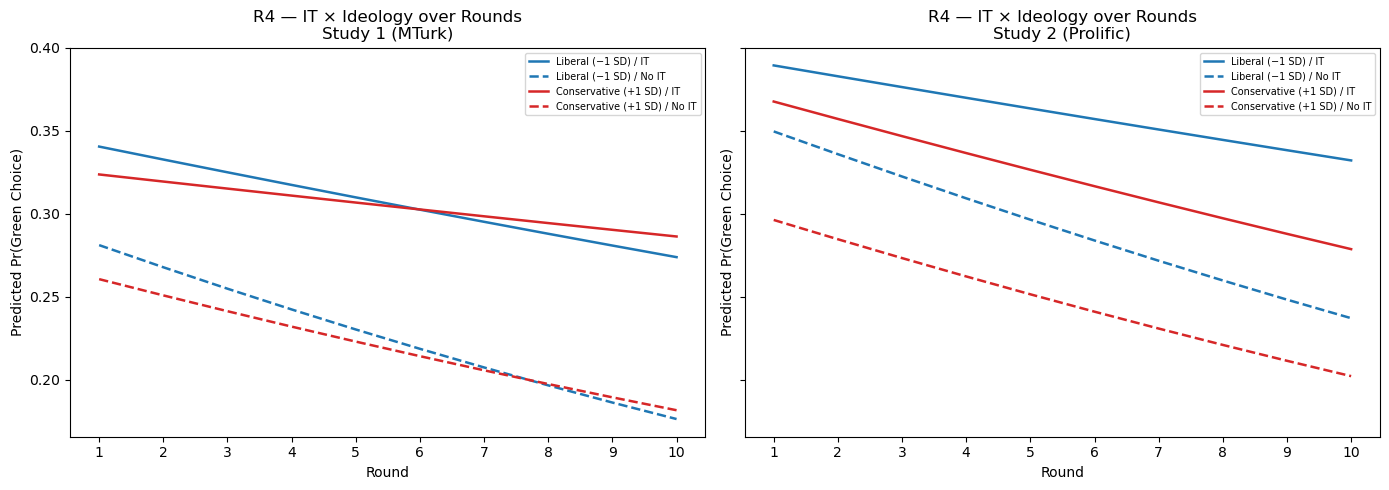

Saved: outputs/fig_r4_round_moderation.png


In [5]:
# ── Cell 5: R4 — Round-level IT × ideology interaction ────────
# Tests whether the IT × ideology moderation changes over the
# course of the 10-round game.
# Three-way formula: IT_present * liberal_z * round
# (includes all two-way interactions and main effects).
#
# Visualised as predicted Pr(green) by round for four groups:
#   Liberal + IT, Liberal + No IT, Conservative + IT, Conservative + No IT.

FORMULA_R4 = (
    "extraction_2 ~ IT_present * liberal_z * round + "
    "GI_present + age + education"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    data = df.dropna(subset=['liberal_z', 'extraction_2',
                              'age', 'education', 'round'])
    try:
        m_r4 = smf.logit(FORMULA_R4, data=data).fit(
            cov_type='cluster',
            cov_kwds={'groups': data['sessioncode']},
            disp=False
        )
    except Exception as e:
        print(f"R4 {name}: {e}")
        continue

    means = {c: data[c].mean()
             for c in ['GI_present', 'age', 'education']
             if c in data.columns}

    for lib_val, colour, lbl_base in [
        (-1.0, '#1f77b4', 'Liberal (−1 SD)'),
        (+1.0, '#d62728', 'Conservative (+1 SD)')
    ]:
        for it_val, ls, it_lbl in [(1, '-', 'IT'), (0, '--', 'No IT')]:
            preds = []
            for rd in range(1, 11):
                row = {'liberal_z': lib_val, 'IT_present': it_val,
                       'round': rd, **means}
                preds.append(m_r4.predict(pd.DataFrame([row]))[0])
            ax.plot(range(1, 11), preds,
                    color=colour, linestyle=ls, lw=1.8,
                    label=f"{lbl_base} / {it_lbl}")

    ax.set_title(f"R4 — IT × Ideology over Rounds\n{PLATFORMS[name]}")
    ax.set_xlabel('Round')
    ax.set_ylabel('Predicted Pr(Green Choice)')
    ax.set_xticks(range(1, 11))
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('outputs/fig_r4_round_moderation.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/fig_r4_round_moderation.png")